# Computer Vision

In the early years of artificial intelligence, computer scientists intended to program computers so as to mimic human behavior. Some of this manifests in the form of robotics, but some others were more software-based, one of these being vision.

Computers themselves (and the abstract concept of the simplest working computer, the Turing Machine) do not have the ability to "see" images in the same way that humans can see an image and make meaning out of it. Therefore, computer vision aims to train computers to take an image, apply mathematical functions, and extract meaning or make predictions from those images.

## What is an Image?

When we see an image with our eyes, it manifests as something that we see, but when we break it down, the image is simply varying amounts of red, green, and blue light entering our eyes in organized patterns. This light is reflected (if we have a physical image, such as a book or painting) or emitted (if we have a digital image displayed on a computer screen).

So what is an image, from the perspective of the computer, since it does not have eyes into which light can enter? Since a computer is displaying the image on its screen, the image has to contain instructions for how to light up the display. Pixels on a computer screen are made up of tiny red, green, and blue lights lit up in specific amounts. So the image file has to contain the numbers that tell the computer how bright to light up each pixel. 

### Pixel Coloring

For nearly all computers, the pixels emit each color according to a specific number; this number ranges from 0 to 255, corresponding to the range for which 8 bits or 1 byte can store. Each pixel gets three of these, corresponding to the amount of red, green, and blue to light up each pixel; these three numbers are often combined in hexadecimal code to form a 6-character long string that maps to a unique color. 

For example, 000000 corresponds to no light for the red, green, and blue components of the pixel, which indicates a black pixel. On the other hand, FFFFFF corresponds to maximum light for all these components, making a white pixel. Any visible color can be made by varying these components, and there are a myriad of tools available to decide what the code is for a specific color as well.

### Pixels in Python

Python has a functionality to not only read in an image as a numerical `numpy` matrix, but also to read in these images into three separate matrices corresponding to the red, green, and blue portions, respectively. Making a single matrix for the image would require equal amounts of red, green, and blue for each pixel, which indicates a black-and-white image.

To look at this first, we can read in this image of some lemons. **NOTE: THIS IMAGE WILL BE CHANGED TO SOMETHING ROYALTY FREE!**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#read in lemons-tree.jpg as a numpy array
lemons = plt.imread('lemons-tree.jpg')

This simple line of code reads in the image as a 3D `numpy` array; in other words, a set of three matrices. These three matrices are the red, green, and blue layers of the image.

If we display the shape of the array, we can see the 3 layers as the third dimension, but we can also see the dimensions of each layer.

In [3]:
lemons.shape

(1067, 1600, 3)

The image is read in as a 1067 x 1600 matrix for each layer. Each of these rows or columns in the matrix corresponds to a pixel position, and multiplying the row and column numbers gives us 1,707,200 pixels. With three layers, this becomes over **5 million** numbers. 

Now imagine if we had to read these in as features for a dataset. This would make a dataset with millions of features, and if we combine this with the thousands of data points usually fed to a machine learning algorithm, we can imagine that this requires high computational intensity.

Modern algorithms typically take advantage of large neural networks to deal with this large number of features. However, with images this large, it is still computationally intensive to run these algorithms. As such, we need to do some preprocessing of our images to help the computer manage the large processing requirement.

## Image Preprocessing

One simple way we can reduce the number of features passed to a machine learning model is to reduce the resolution or size of the image. This simply means fewer pixels, which automatically removes a significant amount of features.

For our example photo, we can try to remove the first and last quarters of the image's width.

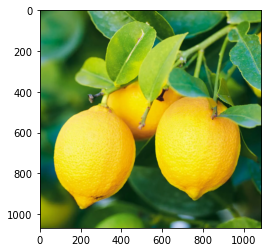

In [6]:
#take the middle portion of the image, leaving a quarter of the width off from
#each side. so we go from 256 to 1344
lemons_middle = lemons[:, 256:1344]

#display the middle portion of the image
plt.imshow(lemons_middle)

This type of processing can be useful for images where the object of interest is in the center of the image. Many images are like this, but this is not always the case, so it is important to make sure you are not removing any important features by chopping off parts of the image.

We can also reduce the resolution of the image. Right now our example image is at a 1067 x 1600 resolution. What if we reduced each dimension by half to make (approximately) a 534 x 800 resolution?

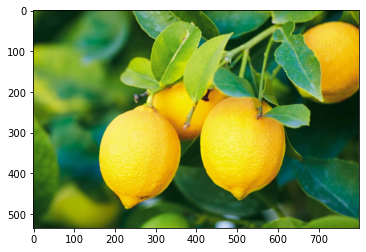

In [7]:
#reduce resolution by a factor of 2 on each side
#so we go from 1067 to 534 and 1600 to 800
lemons_small = lemons[::2, ::2]

#display the reduced resolution image
plt.imshow(lemons_small)

To the human eye, this resolution is still pretty usable; we can easily recognize what is in the image, yet we have reduced the number of features in this image to 1.2 million from the earlier over 5 million. So maybe we can reduce resolution even further; let's try dividing each side by 8.

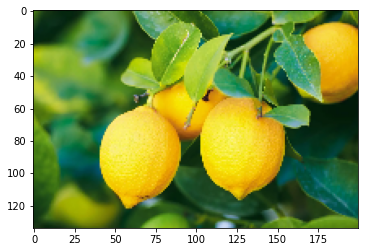

In [9]:
#reduce resolution by a factor of 8 on each side
#so we go from 1067 to 133 and 1600 to 200
lemons_tiny = lemons[::8, ::8]

#display the reduced resolution image
plt.imshow(lemons_tiny)

With these dimensions, we can see that the image is more pixelated but still recognizable. Remarkably, we have now gone to 79,800 features for this image!

This kind of resolution reduction will be crucial when designing your own computer vision tasks, but it is important to make sure you do not reduce this too much so that we do not lose any important features of the image. For an image such as this, we clearly see the benefits of reducing the resolution of the image, but this may not be the case for an image that is more crowded.

As an example, let's try this image of **still working on this one. can we get a busy satellite image, or an aerial view of a city?**

We can see that resolution in this case is detrimental to any recognition efforts. This problem has led to the computer vision problems of *image segmentation* and *image recognition*, where the computer splits an image into respective parts and recognizes an object in an image, respectively.

One final way we can reduce the number of features for an image is to alter the color layers. So far, we have been seeing and working with images that have all colors (red, green, and blue) displaying. What if we only had one color instead?

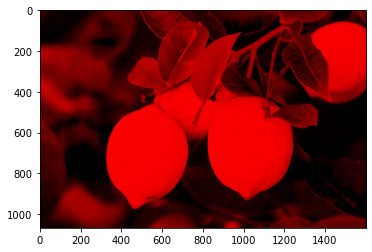

In [10]:
#isolate the red channel of lemons
lemons_red = lemons.copy()
lemons_red[:, :, 1] = 0
lemons_red[:, :, 2] = 0

#display the red channel
plt.imshow(lemons_red)

The lemons shown in this picture are a much brighter shade of red than all of the rest of the photo; this is because the yellow of the lemons is made up of bright red and bright green from the pixels, while the rest of the green background does not require as much red. 

In contrast to red highlighting the lemons, we can also look at another color that may not have as large of an impact, the blue channel.

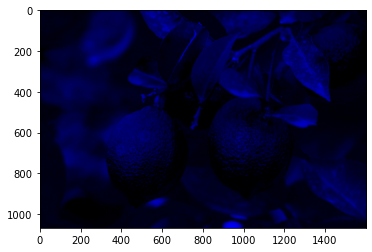

In [11]:
#same as above, but blue channel
lemons_blue = lemons.copy()
lemons_blue[:, :, 0] = 0
lemons_blue[:, :, 1] = 0

#display the blue channel
plt.imshow(lemons_blue)

The blue mostly shows up in the tips of the leaves which have a darker shade of green. However, since most of the image is yellow and green anyway, we can see that in this example, the blue layer is not useful.

When deciding what layers to include or alter, it is important to consult domain knowledge and understand the contents of the dataset. Removing the red layer from our example image could be disastrous, and doing this without knowing the consequences can have far-reaching consequences.